# Comparaison des représentations k-mer

Deux classifieurs entraînés sur les **fréquences k-mer** (84 k-mers/côté, k = 1, 2, 3) :
- **MLP** : le classifieur de PBIP (config `small2`), nourri par les k-mers au lieu des embeddings ;
- **RF** : un RandomForest sur les features concaténées (bact + phage).

Trois façons de calculer les k-mers (modes) :
- **trunc**  : une seule fenêtre tronquée que voient les foundation models (bact : 131 071 pb ; phage : 12 276 pb) ;
- **full**   : la séquence entière, une seule composition moyenne ;
- **chunks** : `N_CHUNKS` fenêtres consécutives au début (par défaut 5), taille par côté (bact 25 000 pb, phage 5 000 pb), une composition par fenêtre, **concaténées** (5 × 84 = 420 dims/côté) — pour capter la variation locale.

Protocole : `N = 10` runs, MCC **et** F1, **dans les deux sens** :
1. train PredPhi → test PredPhi-test + `all` ;
2. train `all` → test PredPhi-train + PredPhi-test.

In [1]:
%cd ../..
!pwd

/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import copy, itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import matthews_corrcoef, f1_score

from main import parse_config, train_nn_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 1. Constantes

In [3]:
KS         = [1, 2, 3]     # tailles de k-mers : 4 + 16 + 64 = 84 features
MEGA_TRUNC = 131071        # fenêtre vue par MegaDNA (bactérie)
NT2_TRUNC  = 12276         # fenêtre vue par NT2 (phage)

# mode "chunks" : N_CHUNKS fenêtres consécutives au début, taille différente par côté
N_CHUNKS         = 4
CHUNK_SIZE_BACT  = MEGA_TRUNC//2   # bactérie (génome long)
CHUNK_SIZE_PHAGE = NT2_TRUNC//2   # phage (génome court)

# mode "split" : séquence ENTIÈRE découpée en N_SPLIT fenêtres de taille égale
N_SPLIT = 5

KMER_COLS  = ["".join(p) for k in KS for p in itertools.product("ACGT", repeat=k)]
CHUNK_COLS = [f"c{j}_{km}" for j in range(N_CHUNKS) for km in KMER_COLS]   # N_CHUNKS * 84
SPLIT_COLS = [f"s{j}_{km}" for j in range(N_SPLIT) for km in KMER_COLS]   # N_SPLIT * 84
print(f"{len(KMER_COLS)} k-mers (k={KS}) ; chunks -> {len(CHUNK_COLS)} dims "
      f"(bact {N_CHUNKS}x{CHUNK_SIZE_BACT} pb | phage {N_CHUNKS}x{CHUNK_SIZE_PHAGE} pb)")
print(f"split  -> {len(SPLIT_COLS)} dims ({N_SPLIT} fenêtres égales sur toute la séquence)")

84 k-mers (k=[1, 2, 3]) ; chunks -> 336 dims (bact 4x65535 pb | phage 4x6138 pb)
split  -> 420 dims (5 fenêtres égales sur toute la séquence)


## 2. Chargement des 3 jeux de données

Les CSV bacteria/phages sont partagés entre train et test PredPhi : on les filtre
aux seules entités présentes dans `couples`.

In [4]:
PRED = "data/perphect-data/predphi"
ALL  = "data/perphect-data/all"

def load_dataset(couples_path, bact_path, phage_path):
    couples = pd.read_csv(couples_path)
    bact    = pd.read_csv(bact_path)
    phage   = pd.read_csv(phage_path)
    bact  = bact [bact ["bacterium_id"].astype(str).isin(couples["bacterium_id"].astype(str))].reset_index(drop=True)
    phage = phage[phage["phage_id"   ].astype(str).isin(couples["phage_id"].astype(str))].reset_index(drop=True)
    return {"couples": couples, "bacteria": bact, "phages": phage}

datasets = {
    "predphi_train": load_dataset(f"{PRED}/predphi_train_dataset.csv", f"{PRED}/bacteria_sequences.csv",     f"{PRED}/bacteriophages_sequences.csv"),
    "predphi_test":  load_dataset(f"{PRED}/predphi_test_dataset.csv",  f"{PRED}/bacteria_sequences.csv",     f"{PRED}/bacteriophages_sequences.csv"),
    "all":           load_dataset(f"{ALL}/couples_df.csv",             f"{ALL}/bacteria_df.csv",             f"{ALL}/phages_df.csv"),
}
for name, d in datasets.items():
    c = d["couples"]
    print(f"{name:14s} : {len(c):5d} couples ({(c.interaction_type==1).sum()} pos / {(c.interaction_type==0).sum()} neg) "
          f"| {len(d['bacteria'])} bactéries | {len(d['phages'])} phages")

predphi_train  :  5702 couples (2851 pos / 2851 neg) | 194 bactéries | 2831 phages
predphi_test   :  1236 couples (618 pos / 618 neg) | 107 bactéries | 618 phages
all            :  7720 couples (2473 pos / 5247 neg) | 226 bactéries | 3201 phages


## 3. Features k-mer : trunc, full et chunks

Pour chaque entité, trois représentations dans `KMERS[dataset][côté][mode]` :

- `trunc` / `full` : 84 k-mers sur une seule fenêtre (tronquée / entière) ;
- `chunks` : 84 k-mers par fenêtre, pour les `N_CHUNKS` premières fenêtres, **concaténés** (5 × 84 = 420 dims). Taille de fenêtre **par côté** : bactérie

(Le calcul `full` sur les génomes bactériens entiers peut prendre quelques minutes ; `chunks` est bien plus rapide.)

In [5]:
def kmer_freqs(seq):
    """Fréquences des k-mers (tailles KS) dans seq -> dict {kmer: freq}."""
    s = str(seq).upper()
    out = {}
    for k in KS:
        tot = max(1, len(s) - k + 1)
        c = Counter(s[i:i+k] for i in range(len(s) - k + 1))
        for km in ("".join(p) for p in itertools.product("ACGT", repeat=k)):
            out[km] = c.get(km, 0) / tot
    return out

def kmer_table(df, id_col, seq_col, trunc):
    """84 k-mers sur une seule fenêtre. trunc=None -> séquence entière."""
    seqs = df[seq_col].map(lambda s: str(s)[:trunc] if trunc is not None else str(s))
    K = pd.DataFrame(list(seqs.map(kmer_freqs)), index=df[id_col].astype(str))[KMER_COLS]
    return K.astype(np.float32)

def kmer_chunks(seq, chunk_size, n_chunks=N_CHUNKS):
    """Concatène les k-mer freqs des n_chunks premières fenêtres de chunk_size (zéro-padding si court)."""
    s = str(seq).upper()
    vec = {}
    for j in range(n_chunks):
        f = kmer_freqs(s[j * chunk_size:(j + 1) * chunk_size])
        for km in KMER_COLS:
            vec[f"c{j}_{km}"] = f[km]
    return vec

def kmer_chunks_table(df, id_col, seq_col, chunk_size):
    """N_CHUNKS x 84 k-mers : une composition par fenêtre, concaténée."""
    rows = df[seq_col].map(lambda s: kmer_chunks(s, chunk_size))
    K = pd.DataFrame(list(rows), index=df[id_col].astype(str))[CHUNK_COLS]
    return K.astype(np.float32)

def kmer_split(seq, n_parts=N_SPLIT):
    """Découpe la séquence ENTIÈRE en n_parts fenêtres de taille égale ; k-mers de chacune, concaténés."""
    s = str(seq).upper()
    L = len(s)
    vec = {}
    for j in range(n_parts):
        a, b = (L * j) // n_parts, (L * (j + 1)) // n_parts
        f = kmer_freqs(s[a:b])
        for km in KMER_COLS:
            vec[f"s{j}_{km}"] = f[km]
    return vec

def kmer_split_table(df, id_col, seq_col):
    """N_SPLIT x 84 k-mers : séquence entière découpée en parts égales, concaténées."""
    K = pd.DataFrame(list(df[seq_col].map(kmer_split)), index=df[id_col].astype(str))[SPLIT_COLS]
    return K.astype(np.float32)

KMERS = {}
for name, d in datasets.items():
    KMERS[name] = {
        "bact": {
            "trunc":  kmer_table(d["bacteria"], "bacterium_id", "bacterium_sequence", MEGA_TRUNC),
            "full":   kmer_table(d["bacteria"], "bacterium_id", "bacterium_sequence", None),
        },
        "phage": {
            "trunc":  kmer_table(d["phages"], "phage_id", "phage_sequence", NT2_TRUNC),
            "full":   kmer_table(d["phages"], "phage_id", "phage_sequence", None),
        },
    }
    print(f"{name:14s} : bact {len(KMERS[name]['bact']['trunc'])} | phage {len(KMERS[name]['phage']['trunc'])}")

predphi_train  : bact 194 | phage 2831
predphi_test   : bact 107 | phage 618
all            : bact 226 | phage 3201


## 4. Classifieurs sur k-mers : MLP (PBIP) et RandomForest

- **MLP** : réutilise le MLP de `small2`, nourri par les vecteurs k-mer. `KMER_TRAIN_NOISE_STD = 0`.
- **RF** : `RandomForestClassifier` sur les features bact + phage concaténées, un seed par run.

In [6]:
config_s2 = parse_config(config_path="output/pbip/small2/training_config.yaml")
N_RUNS = 10
KMER_TRAIN_NOISE_STD = 0.0
MODES = ("trunc", "full")

from sklearn.ensemble import RandomForestClassifier

# ---------- construction des entrees k-mer ----------
def build_kmer_dataset(name, mode):
    """Dataset facon PBIP : 'embeddings' = vecteurs k-mer du mode choisi."""
    d = datasets[name]
    B, P = KMERS[name]["bact"][mode], KMERS[name]["phage"][mode]
    rows = []
    for c in d["couples"].itertuples():
        bid, pid = str(c.bacterium_id), str(c.phage_id)
        if bid in B.index and pid in P.index:
            rows.append({
                "bacterium_embedding": torch.tensor(B.loc[bid].values, dtype=torch.float32),
                "phage_embedding":     torch.tensor(P.loc[pid].values, dtype=torch.float32),
                "interaction_type":    int(c.interaction_type),
            })
    return pd.DataFrame(rows)

def build_kmer_matrix(name, mode):
    """X (couples x features concatenees bact+phage), y, pour le RandomForest."""
    d = datasets[name]
    B, P = KMERS[name]["bact"][mode], KMERS[name]["phage"][mode]
    X, y = [], []
    for c in d["couples"].itertuples():
        bid, pid = str(c.bacterium_id), str(c.phage_id)
        if bid in B.index and pid in P.index:
            X.append(np.concatenate([B.loc[bid].values, P.loc[pid].values]))
            y.append(int(c.interaction_type))
    return np.asarray(X, dtype=np.float32), np.asarray(y)

# ---------- MLP (PBIP) ----------
def train_pbip(ds_train, noise_std=None):
    bs = len(ds_train["bacterium_embedding"].iloc[0])
    ps = len(ds_train["phage_embedding"].iloc[0])
    m = config_s2.classifier(bs, ps, **config_s2.classifier_params).to(device)
    tcfg = config_s2.training_config
    if noise_std is not None:
        tcfg = copy.deepcopy(tcfg)
        tcfg.training_noise_std = noise_std
    train_nn_model(ds_train, m, tcfg, device=device, verbose=0)
    m.eval()
    return m

def eval_pbip(m, ds):
    preds, labels = [], []
    with torch.no_grad():
        for _, row in ds.iterrows():
            out = m(row["bacterium_embedding"].unsqueeze(0).to(device),
                    row["phage_embedding"].unsqueeze(0).to(device))
            preds.append(int(out.argmax(dim=1).item()))
            labels.append(int(row["interaction_type"]))
    preds, labels = np.array(preds), np.array(labels)
    return {"mcc": matthews_corrcoef(labels, preds), "f1": f1_score(labels, preds, zero_division=0)}

# ---------- boucles d'experience ----------
def run_direction(train_name, test_names, modes=MODES):
    """MLP : entraine sur train_name, evalue sur test_names, pour chaque mode."""
    recs = []
    for mode in modes:
        ds_train = build_kmer_dataset(train_name, mode)
        tests = {t: build_kmer_dataset(t, mode) for t in test_names}
        print(f"[MLP {mode:6s}] train={train_name}({len(ds_train)}, dim={len(ds_train['bacterium_embedding'].iloc[0])})  " +
              "  ".join(f"{t}={len(v)}" for t, v in tests.items()))
        for run in range(N_RUNS):
            m = train_pbip(ds_train, noise_std=KMER_TRAIN_NOISE_STD)
            for t, dv in tests.items():
                recs.append({"clf": "MLP", "mode": mode, "split": t, "run": run, **eval_pbip(m, dv)})
    return pd.DataFrame(recs)

def run_rf_direction(train_name, test_names, modes=MODES, n_seeds=None):
    """RF : meme protocole, RandomForest sur les features k-mer concatenees."""
    n_seeds = n_seeds or N_RUNS
    recs = []
    for mode in modes:
        Xtr, ytr = build_kmer_matrix(train_name, mode)
        tests = {t: build_kmer_matrix(t, mode) for t in test_names}
        print(f"[RF  {mode:6s}] train={train_name}({len(ytr)}, dim={Xtr.shape[1]})  " +
              "  ".join(f"{t}={len(v[1])}" for t, v in tests.items()))
        for seed in range(n_seeds):
            clf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=seed)
            clf.fit(Xtr, ytr)
            for t, (Xt, yt) in tests.items():
                pred = clf.predict(Xt)
                recs.append({"clf": "RF", "mode": mode, "split": t, "run": seed,
                             "mcc": matthews_corrcoef(yt, pred),
                             "f1": f1_score(yt, pred, zero_division=0)})
    return pd.DataFrame(recs)

def summarize(df):
    for (clf, mode, split), v in df.groupby(["clf", "mode", "split"]):
        print(f"  {clf:3s} {mode:6s} {split:14s} MCC {v.mcc.mean():.3f}+/-{v.mcc.std():.3f} | "
              f"F1 {v.f1.mean():.3f}+/-{v.f1.std():.3f}")

# ---------- plot combine : une barre par (clf, mode), 2 panneaux MCC / F1 ----------
def plot_compare(df, title):
    splits = list(dict.fromkeys(df["split"]))
    series = sorted(set(map(tuple, df[["clf", "mode"]].values.tolist())))
    n, x = len(series), np.arange(len(splits))
    w = 0.8 / n
    cmap = plt.cm.tab10
    fig, axes = plt.subplots(1, 2, figsize=(7 + 1.6 * len(splits), 5))
    for ax, metric in zip(axes, ["mcc", "f1"]):
        summ = df.groupby(["clf", "mode", "split"])[metric].agg(["mean", "std"])
        for i, key in enumerate(series):
            means = [summ.loc[(*key, s), "mean"] if (*key, s) in summ.index else 0 for s in splits]
            stds  = [summ.loc[(*key, s), "std"]  if (*key, s) in summ.index else 0 for s in splits]
            ax.bar(x + (i - (n - 1) / 2) * w, means, w, yerr=stds, capsize=2,
                   label=f"{key[0]} {key[1]}", color=cmap(i % 10), alpha=0.9)
        ax.set_xticks(x); ax.set_xticklabels(splits)
        ax.set_ylabel(metric.upper()); ax.axhline(0, color="grey", lw=0.6)
        ax.set_title(metric.upper()); ax.grid(axis="y", ls=":", alpha=0.5)
    axes[0].legend(fontsize=8, ncol=2)
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()

[INFO] Configuration loaded from output/pbip/small2/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=False epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=1 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TruncateStrategy(), overlap=0, model_name='nucleotide-transformer-v2-250m-multi-species')], compute_phages_embeddings=[True], bacteria_embedding_models=[MegaDNA(merging_strategy=TruncateSt

## 5. Sens 1 : train PredPhi → test PredPhi-test + `all`

[MLP trunc ] train=predphi_train(5702, dim=84)  predphi_test=1236  all=7720
[MLP full  ] train=predphi_train(5702, dim=84)  predphi_test=1236  all=7720
[RF  trunc ] train=predphi_train(5702, dim=168)  predphi_test=1236  all=7720
[RF  full  ] train=predphi_train(5702, dim=168)  predphi_test=1236  all=7720
  MLP full   all            MCC 0.281+/-0.028 | F1 0.554+/-0.010
  MLP full   predphi_test   MCC 0.551+/-0.052 | F1 0.774+/-0.035
  MLP trunc  all            MCC 0.244+/-0.015 | F1 0.541+/-0.006
  MLP trunc  predphi_test   MCC 0.489+/-0.053 | F1 0.746+/-0.036
  RF  full   all            MCC 0.212+/-0.020 | F1 0.529+/-0.007
  RF  full   predphi_test   MCC 0.425+/-0.048 | F1 0.606+/-0.048
  RF  trunc  all            MCC 0.332+/-0.029 | F1 0.582+/-0.014
  RF  trunc  predphi_test   MCC 0.279+/-0.038 | F1 0.424+/-0.045


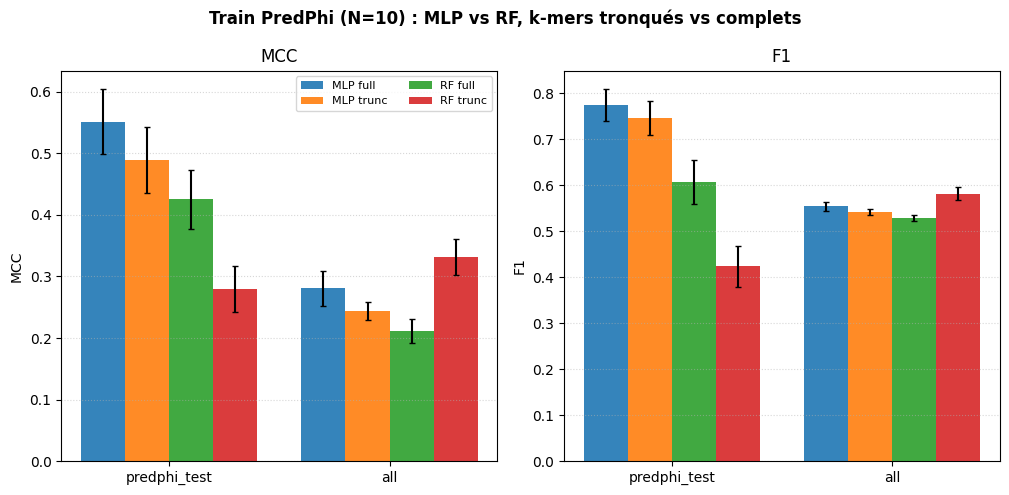

In [7]:
df_a = pd.concat([
    run_direction("predphi_train", ["predphi_test", "all"]),
    run_rf_direction("predphi_train", ["predphi_test", "all"]),
], ignore_index=True)
summarize(df_a)
plot_compare(df_a, f"Train PredPhi (N={N_RUNS}) : MLP vs RF, k-mers tronqués vs complets")

## 6. Sens 2 : train `all` → test PredPhi-train + PredPhi-test

Overlap au niveau couple négligeable (`all` ∩ predphi_train = 0 ; `all` ∩ predphi_test = 7 / 1214),
donc c'est un vrai test de généralisation en sens inverse.

[MLP trunc ] train=all(7720, dim=84)  predphi_train=5702  predphi_test=1236
[MLP full  ] train=all(7720, dim=84)  predphi_train=5702  predphi_test=1236
[RF  trunc ] train=all(7720, dim=168)  predphi_train=5702  predphi_test=1236
[RF  full  ] train=all(7720, dim=168)  predphi_train=5702  predphi_test=1236
  MLP full   predphi_test   MCC 0.269+/-0.058 | F1 0.572+/-0.068
  MLP full   predphi_train  MCC 0.483+/-0.212 | F1 0.703+/-0.198
  MLP trunc  predphi_test   MCC 0.229+/-0.046 | F1 0.501+/-0.085
  MLP trunc  predphi_train  MCC 0.600+/-0.018 | F1 0.805+/-0.005
  RF  full   predphi_test   MCC 0.424+/-0.014 | F1 0.646+/-0.010
  RF  full   predphi_train  MCC 0.689+/-0.002 | F1 0.828+/-0.002
  RF  trunc  predphi_test   MCC 0.357+/-0.018 | F1 0.580+/-0.015
  RF  trunc  predphi_train  MCC 0.668+/-0.003 | F1 0.815+/-0.002


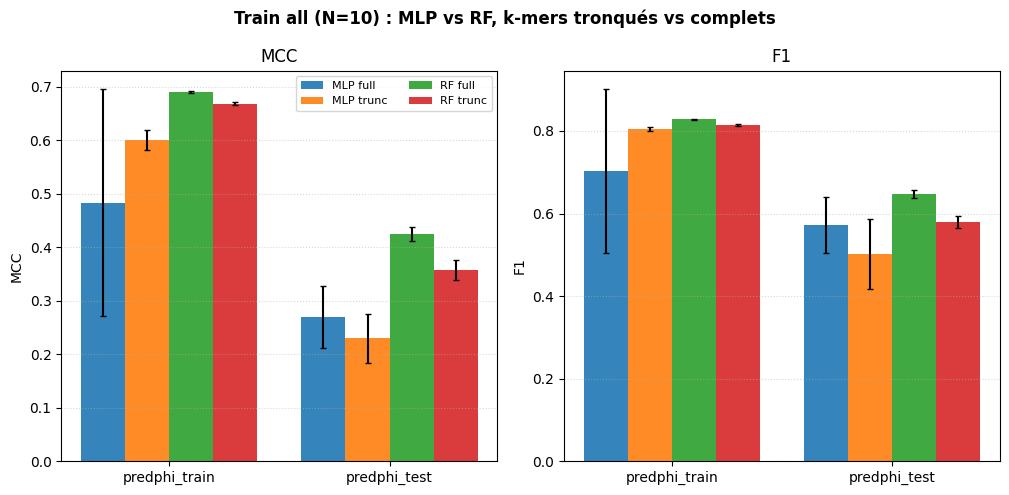

In [8]:
df_b = pd.concat([
    run_direction("all", ["predphi_train", "predphi_test"]),
    run_rf_direction("all", ["predphi_train", "predphi_test"]),
], ignore_index=True)
summarize(df_b)
plot_compare(df_b, f"Train all (N={N_RUNS}) : MLP vs RF, k-mers tronqués vs complets")

## 7. Test de biais : un seul côté suffit-il ?

Pour détecter un biais du dataset, on entraîne les **mêmes** classifieurs (MLP PBIP + RF)
avec **un seul côté** des features :
- **bact** : seules les k-mers de la bactérie (côté phage mis à zéro pour le MLP) ;
- **phage** : seules les k-mers du phage ;
- **both** : référence, les deux côtés (comme le vrai modèle).

**Lecture.** Si `bact` ou `phage` seul atteint un MCC proche de `both`, le modèle exploite
surtout **une entité isolée** (certains phages/bactéries quasi toujours positifs ou négatifs)
plutôt que la vraie interaction de la paire → **biais / fuite**. Un score à un seul côté proche
de 0 est au contraire rassurant. Mode fixé à `trunc` (la fenêtre réellement vue par les
foundation models).

In [9]:
# ---------- TEST DE BIAIS : entrainer sur UN SEUL cote ----------
# Si un classifieur predit l'infection avec SEULEMENT le phage (ou SEULEMENT la bacterie),
# un score eleve trahit un BIAIS du dataset : le label depend surtout d'une entite isolee
# (certains phages/bacteries quasi toujours pos ou neg) et non de la vraie interaction de paire.
# Reference = "both" (les deux cotes). Mode fixe a "trunc". MLP : le cote non teste est mis a ZERO.

def build_kmer_matrix_side(name, mode, side):
    """X (couples x features d'UN SEUL cote), y. side in {'bact','phage'}. Memes couples que build_kmer_matrix."""
    d = datasets[name]
    B, P = KMERS[name]["bact"][mode], KMERS[name]["phage"][mode]
    X, y = [], []
    for c in d["couples"].itertuples():
        bid, pid = str(c.bacterium_id), str(c.phage_id)
        if bid in B.index and pid in P.index:
            X.append((B.loc[bid] if side == "bact" else P.loc[pid]).values)
            y.append(int(c.interaction_type))
    return np.asarray(X, dtype=np.float32), np.asarray(y)

def build_kmer_dataset_side(name, mode, side):
    """Comme build_kmer_dataset mais met a ZERO le cote NON teste (le MLP ne voit qu'un cote)."""
    ds = build_kmer_dataset(name, mode).copy()
    zcol = "phage_embedding" if side == "bact" else "bacterium_embedding"
    dim = len(ds[zcol].iloc[0])
    ds[zcol] = [torch.zeros(dim, dtype=torch.float32) for _ in range(len(ds))]
    return ds

def run_bias_direction(train_name, test_names, mode="trunc"):
    """Compare both / bact-seul / phage-seul, pour RF et MLP. Colonne 'mode' = variante de cote."""
    recs = []
    # --- RandomForest : un seul cote de features ---
    rf_build = {"both":  lambda nm: build_kmer_matrix(nm, mode),
                "bact":  lambda nm: build_kmer_matrix_side(nm, mode, "bact"),
                "phage": lambda nm: build_kmer_matrix_side(nm, mode, "phage")}
    for v, build in rf_build.items():
        Xtr, ytr = build(train_name)
        tests = {t: build(t) for t in test_names}
        print(f"[RF  {v:5s}] train={train_name}({len(ytr)}, dim={Xtr.shape[1]})  " +
              "  ".join(f"{t}={len(yt)}" for t, (Xt, yt) in tests.items()))
        for seed in range(N_RUNS):
            clf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=seed).fit(Xtr, ytr)
            for t, (Xt, yt) in tests.items():
                pred = clf.predict(Xt)
                recs.append({"clf": "RF", "mode": v, "split": t, "run": seed,
                             "mcc": matthews_corrcoef(yt, pred),
                             "f1": f1_score(yt, pred, zero_division=0)})
    # --- MLP (PBIP) : cote non teste mis a zero ---
    mlp_build = {"both":  lambda nm: build_kmer_dataset(nm, mode),
                 "bact":  lambda nm: build_kmer_dataset_side(nm, mode, "bact"),
                 "phage": lambda nm: build_kmer_dataset_side(nm, mode, "phage")}
    for v, build in mlp_build.items():
        ds_train = build(train_name)
        tests = {t: build(t) for t in test_names}
        print(f"[MLP {v:5s}] train={train_name}({len(ds_train)})  " +
              "  ".join(f"{t}={len(dv)}" for t, dv in tests.items()))
        for run in range(N_RUNS):
            m = train_pbip(ds_train, noise_std=KMER_TRAIN_NOISE_STD)
            for t, dv in tests.items():
                recs.append({"clf": "MLP", "mode": v, "split": t, "run": run, **eval_pbip(m, dv)})
    return pd.DataFrame(recs)

[RF  both ] train=predphi_train(5702, dim=168)  predphi_test=1236  all=7720
[RF  bact ] train=predphi_train(5702, dim=84)  predphi_test=1236  all=7720
[RF  phage] train=predphi_train(5702, dim=84)  predphi_test=1236  all=7720
[MLP both ] train=predphi_train(5702)  predphi_test=1236  all=7720
[MLP bact ] train=predphi_train(5702)  predphi_test=1236  all=7720
[MLP phage] train=predphi_train(5702)  predphi_test=1236  all=7720
  MLP bact   all            MCC 0.313+/-0.007 | F1 0.569+/-0.003
  MLP bact   predphi_test   MCC -0.065+/-0.019 | F1 0.037+/-0.006
  MLP both   all            MCC 0.255+/-0.020 | F1 0.546+/-0.008
  MLP both   predphi_test   MCC 0.473+/-0.065 | F1 0.739+/-0.042
  MLP phage  all            MCC 0.180+/-0.036 | F1 0.506+/-0.014
  MLP phage  predphi_test   MCC 0.013+/-0.010 | F1 0.514+/-0.023
  RF  bact   all            MCC 0.296+/-0.000 | F1 0.552+/-0.000
  RF  bact   predphi_test   MCC -0.038+/-0.026 | F1 0.004+/-0.003
  RF  both   all            MCC 0.332+/-0.029 | F1 

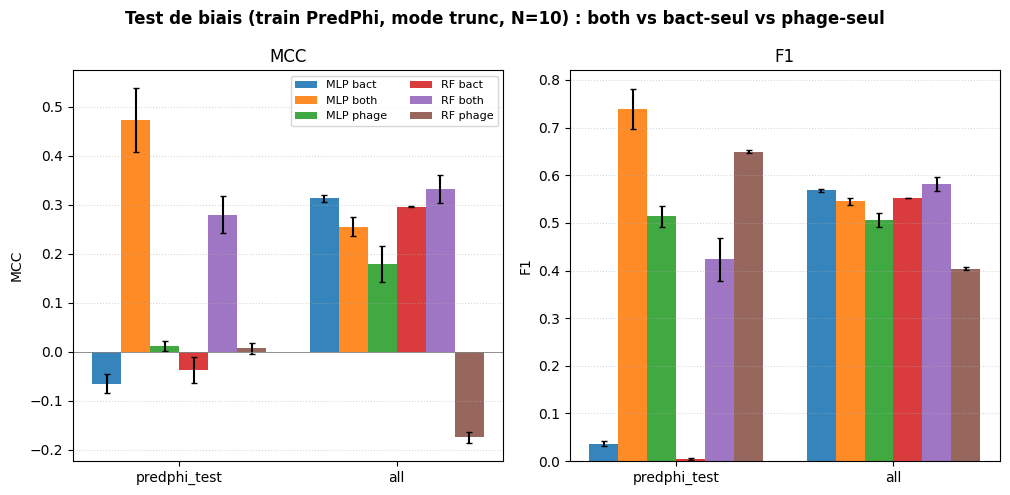

In [10]:
df_bias = run_bias_direction("predphi_train", ["predphi_test", "all"], mode="trunc")
summarize(df_bias)
plot_compare(df_bias, f"Test de biais (train PredPhi, mode trunc, N={N_RUNS}) : both vs bact-seul vs phage-seul")

## 8. Biais k-mer positifs / négatifs : trunc vs full

Si les négatifs diffèrent systématiquement des positifs sur la seule composition,
le classifieur peut apprendre un raccourci au lieu du signal biologique. On mesure
l'écart entre distributions pos/neg de chaque fréquence k-mer avec la statistique
de **Kolmogorov-Smirnov** (0 = distributions identiques, 1 = disjointes).

Contrairement à un écart de médianes, le KS compare les distributions **entières**
(forme comprise) et ne dépend pas de l'ordre de grandeur de la fréquence, ce qui
rend les k-mers comparables entre eux.

Le calcul est fait pour les trois jeux et les **deux modes** (`trunc` = fenêtre vue
par le modèle, `full` = génome entier), afin de vérifier si le biais observé sur
`all` tient à la troncature ou s'il est une propriété du jeu de données.

In [11]:
# 8. KS pos/neg sur les 84 k-mers, par cote et par mode (trunc / full).
from scipy.stats import ks_2samp

THR = 0.10   # seuil KS : ecart de distribution juge notable

def kmer_couple_matrix(name, side, mode):
    """Frequences k-mer propagees par couple (une ligne par couple)."""
    c = datasets[name]["couples"]
    idc = "bacterium_id" if side == "bact" else "phage_id"
    return KMERS[name][side][mode].loc[c[idc].astype(str)]

def ks_table(mode):
    """KS pos/neg pour chaque (cote, k-mer), colonne par dataset."""
    rows = {}
    for name in datasets:
        c = datasets[name]["couples"]
        pos = (c["interaction_type"] == 1).values
        for side in ("bact", "phage"):
            K = kmer_couple_matrix(name, side, mode)
            for km in KMER_COLS:
                v = K[km].values.astype(float)
                rows.setdefault((side, km), {})[name] = ks_2samp(v[pos], v[~pos]).statistic
    return pd.DataFrame(rows).T.rename_axis(["side", "kmer"])

ks_by_mode = {}
for mode in ("trunc", "full"):
    b = ks_table(mode)
    ks_by_mode[mode] = b
    print(f"=== mode {mode} : k-mers discriminants (KS > {THR:.2f}) ===")
    for name in b.columns:
        print(f"  {name:14s} : {(b[name] > THR).sum():3d}/{len(b)} k-mers  "
              f"| KS median={b[name].median():.3f}  max={b[name].max():.3f}")
    print()

# Comparaison directe trunc vs full du KS median, par dataset et par cote
print("KS median par cote (trunc -> full) :")
for name in datasets:
    for side in ("bact", "phage"):
        t = ks_by_mode["trunc"].loc[side, name].median()
        f = ks_by_mode["full"].loc[side, name].median()
        print(f"  {name:14s} {side:5s} : {t:.3f} -> {f:.3f}")

=== mode trunc : k-mers discriminants (KS > 0.10) ===
  predphi_train  :  84/168 k-mers  | KS median=0.147  max=0.577
  predphi_test   :  84/168 k-mers  | KS median=0.086  max=0.353
  all            : 163/168 k-mers  | KS median=0.318  max=0.518

=== mode full : k-mers discriminants (KS > 0.10) ===
  predphi_train  :  84/168 k-mers  | KS median=0.147  max=0.587
  predphi_test   :  84/168 k-mers  | KS median=0.097  max=0.311
  all            : 168/168 k-mers  | KS median=0.329  max=0.521

KS median par cote (trunc -> full) :
  predphi_train  bact  : 0.493 -> 0.515
  predphi_train  phage : 0.021 -> 0.022
  predphi_test   bact  : 0.221 -> 0.206
  predphi_test   phage : 0.034 -> 0.032
  all            bact  : 0.297 -> 0.323
  all            phage : 0.372 -> 0.392


-> doc/images/kmer_biais_bact_pos_neg_trunc.png


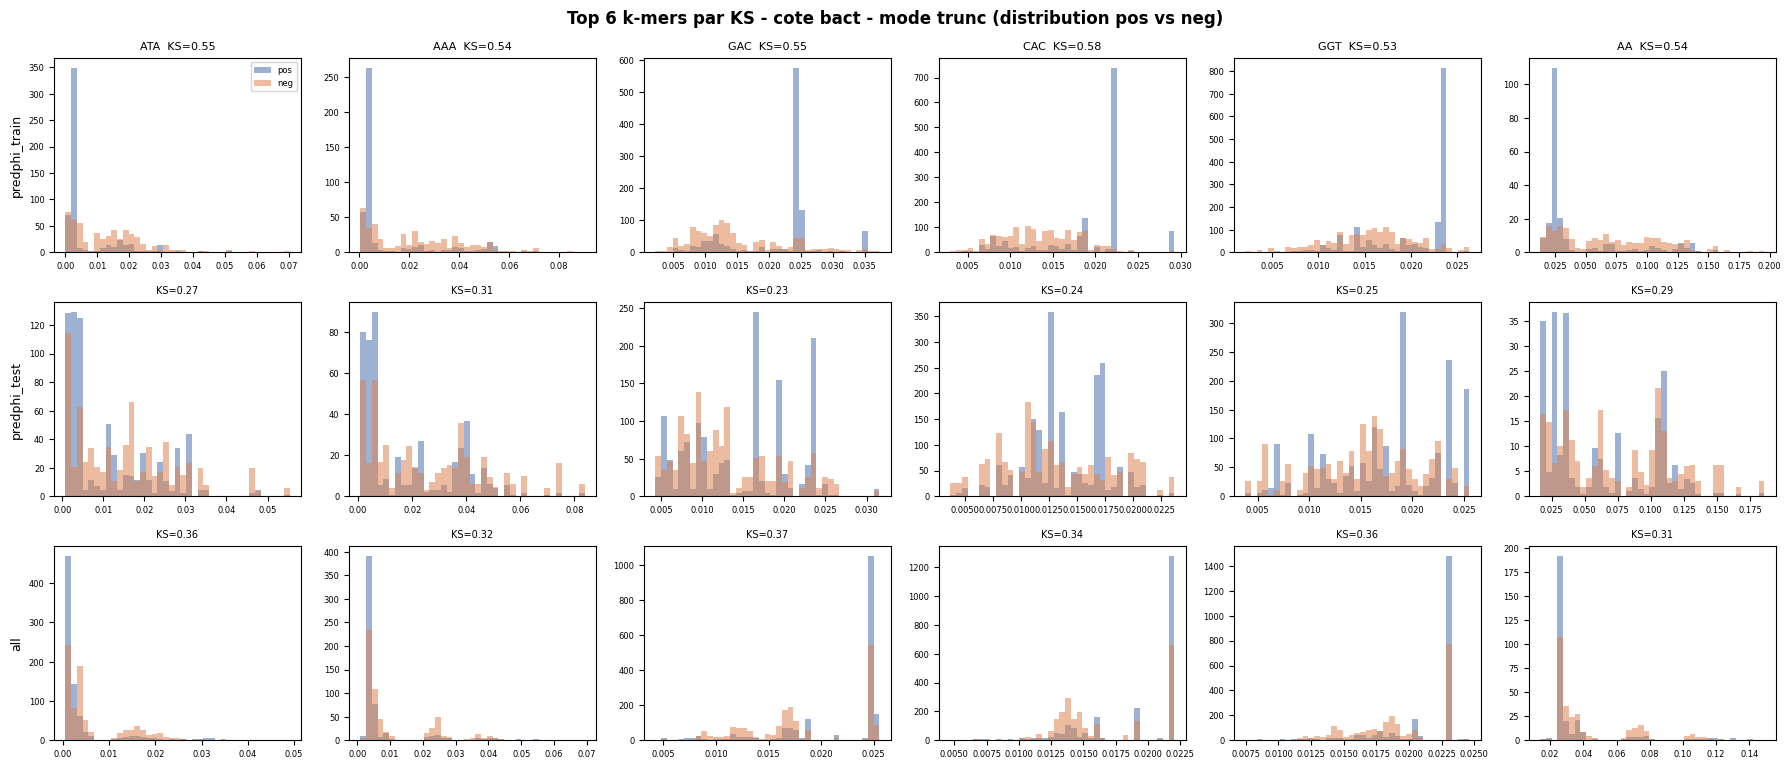

-> doc/images/kmer_biais_phage_pos_neg_trunc.png


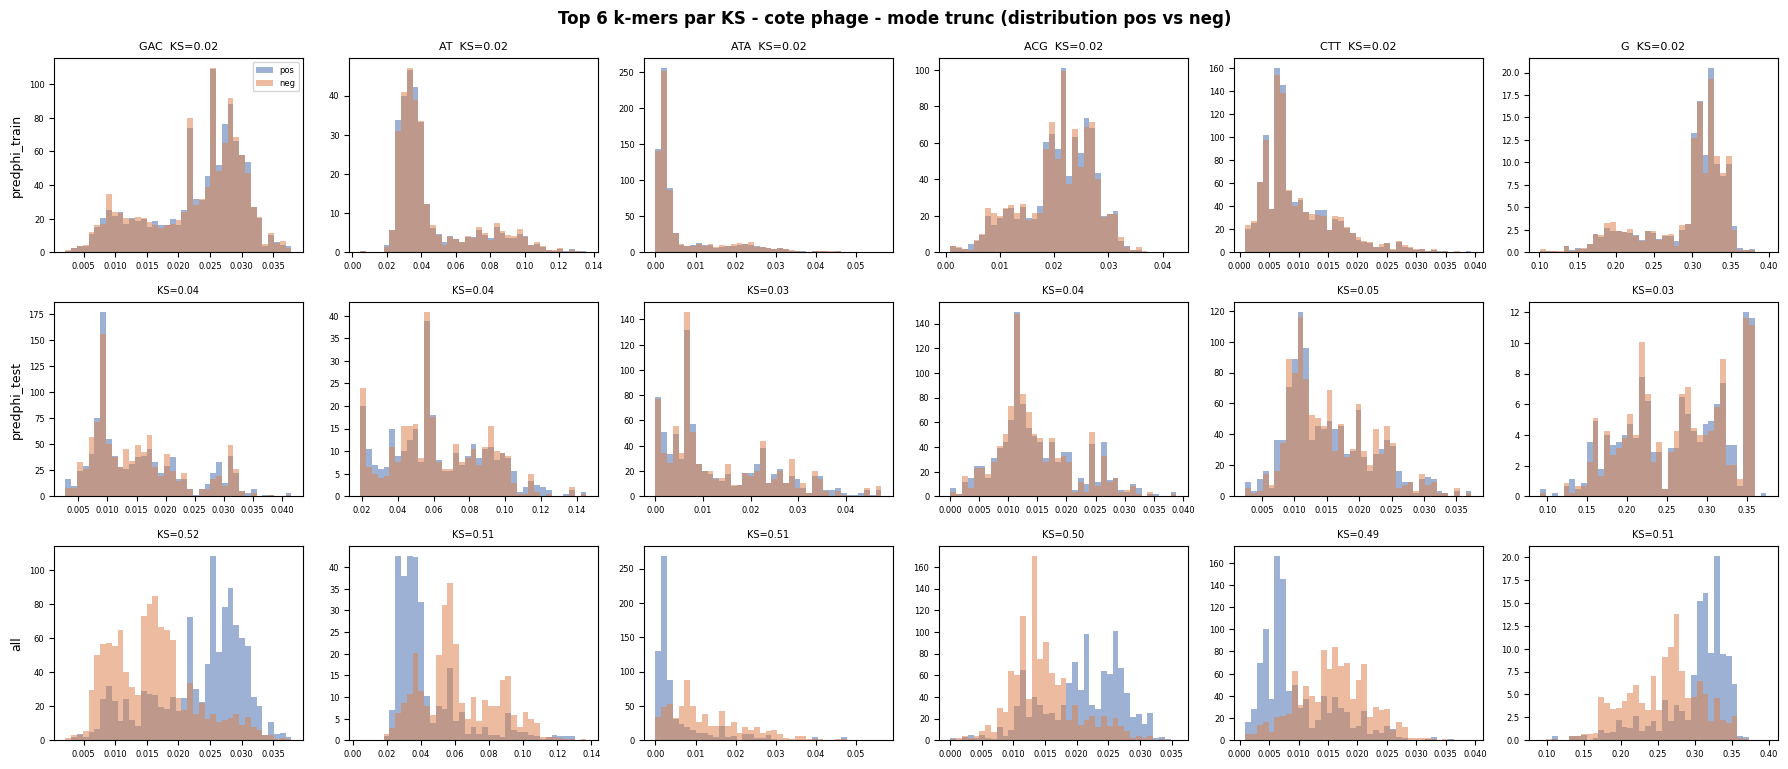

-> doc/images/kmer_biais_bact_pos_neg_full.png


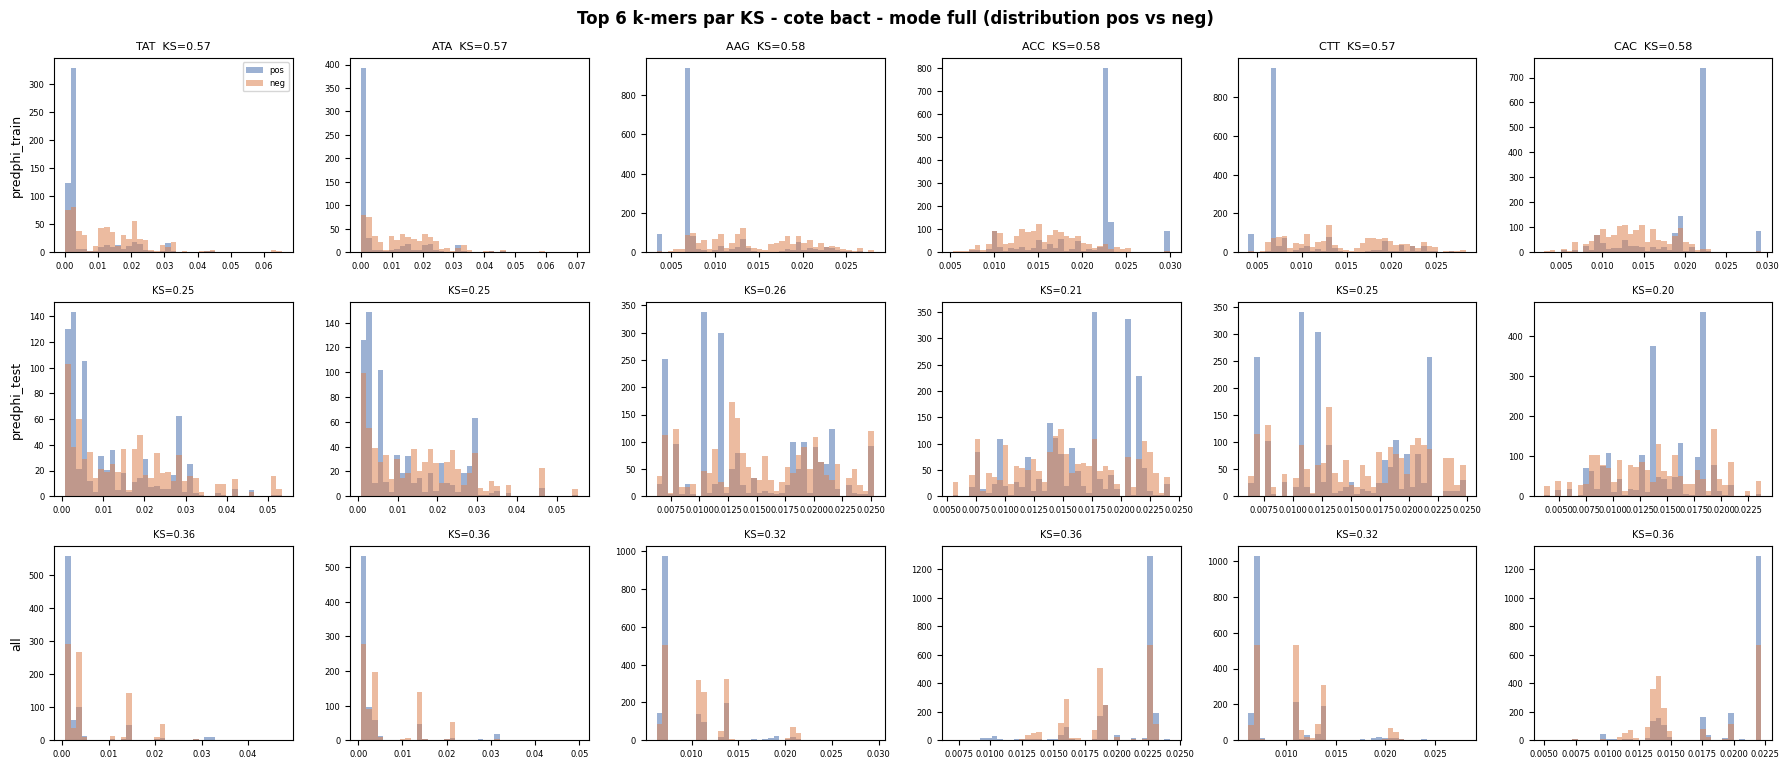

-> doc/images/kmer_biais_phage_pos_neg_full.png


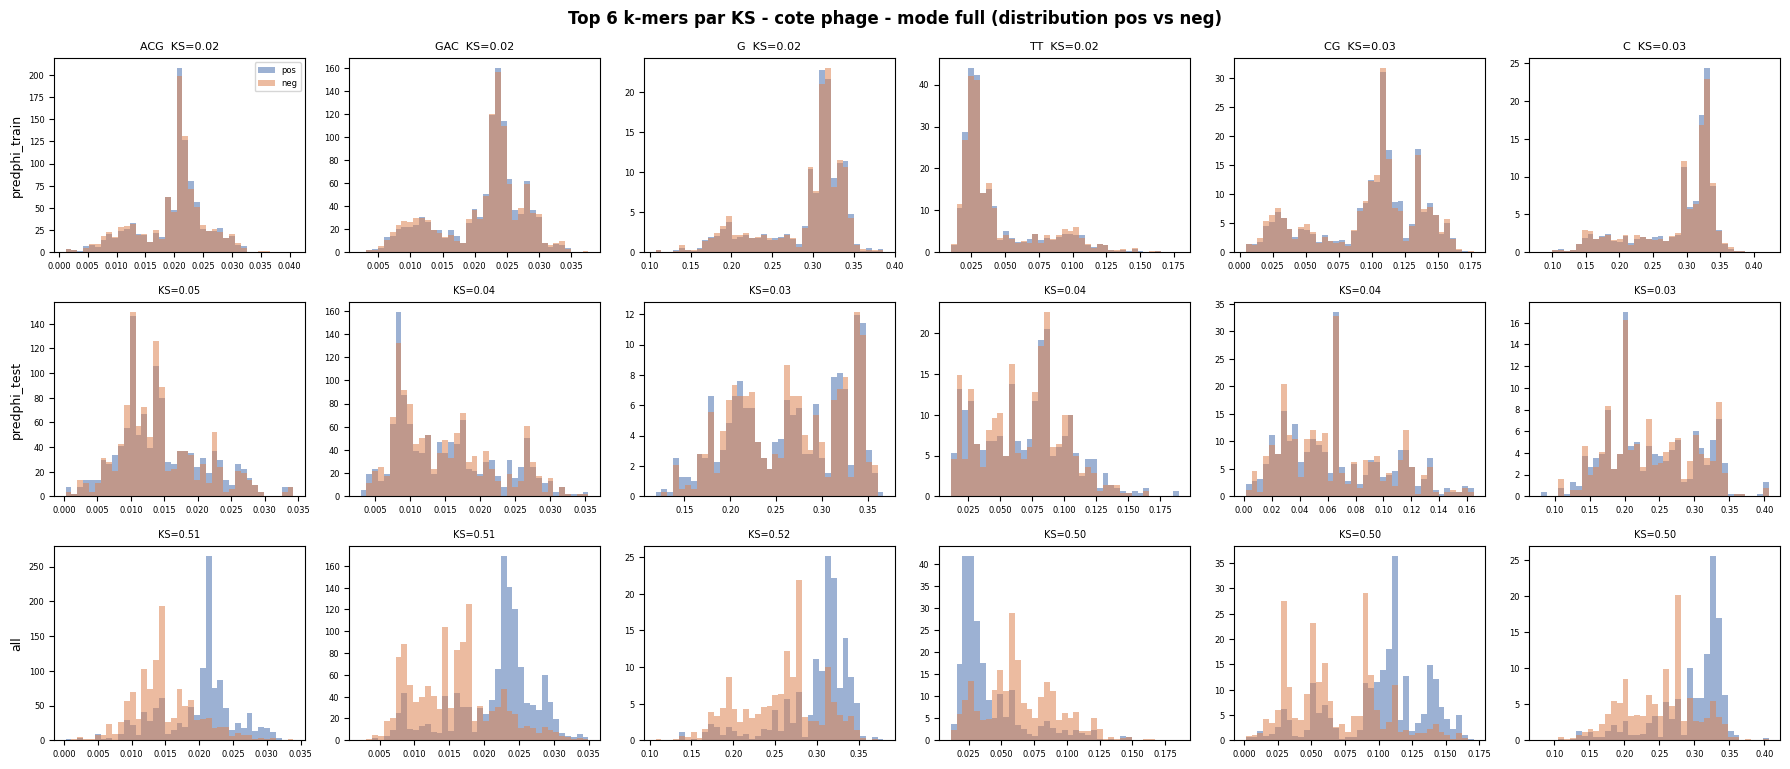

In [12]:
# 8b. Distribution superposee pos/neg des top-k k-mers les plus discriminants, par mode.
TOP = 6   # nombre de k-mers par cote

def kmer_values(name, side, mode, kmer):
    """(valeurs_pos, valeurs_neg) de la frequence d'un k-mer, propagee par couple."""
    c = datasets[name]["couples"]
    pos = (c["interaction_type"] == 1).values
    v = kmer_couple_matrix(name, side, mode)[kmer].values.astype(float)
    return v[pos], v[~pos]

for mode in ("trunc", "full"):
    b = ks_by_mode[mode]
    ks_mean = b.mean(axis=1)          # classement par KS moyen sur les 3 datasets
    for side in ("bact", "phage"):
        kmers = ks_mean.loc[side].sort_values(ascending=False).head(TOP).index.tolist()
        fig, axes = plt.subplots(len(datasets), TOP,
                                 figsize=(3.0 * TOP, 2.6 * len(datasets)))
        for i, name in enumerate(datasets):
            for j, km in enumerate(kmers):
                ax = axes[i, j]
                vp, vn = kmer_values(name, side, mode, km)
                lo, hi = min(vp.min(), vn.min()), max(vp.max(), vn.max())
                bins = np.linspace(lo, hi, 40) if hi > lo else 40
                ax.hist(vp, bins=bins, alpha=0.55, color="#4C72B0", label="pos", density=True)
                ax.hist(vn, bins=bins, alpha=0.55, color="#DD8452", label="neg", density=True)
                ks = b.loc[(side, km), name]
                ax.set_title(f"{km}  KS={ks:.2f}" if i == 0 else f"KS={ks:.2f}",
                             fontsize=8 if i == 0 else 7)
                ax.tick_params(labelsize=6)
                if j == 0:
                    ax.set_ylabel(name, fontsize=9)
                if i == 0 and j == 0:
                    ax.legend(fontsize=6)
        plt.suptitle(f"Top {TOP} k-mers par KS - cote {side} - mode {mode} "
                     f"(distribution pos vs neg)", fontweight="bold")
        plt.tight_layout()
        out = f"doc/images/kmer_biais_{side}_pos_neg_{mode}.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"-> {out}")
        plt.show()